# V0- Simulating a simple orbit and LEO/MEO constellation

Our assumptions

For V0:

Earth is a perfect sphere.

Earth is stationary.

Orbits are circular.

No atmospheric drag.

No Earth's oblateness.

No solar/lunar perturbations.

We use an Earth-Centered Inertial-like frame.

SI units: meters, seconds, kilograms.

Those simplifications are intentional. Later we'll add realism one layer at a time.

In [61]:
import numpy as np
import matplotlib.pyplot as plt

In [62]:
#Defining earth
# Earth parameters

R_EARTH = 6_378_137.0       # Earth radius [m](We're using the WGS-84 equatorial radius for now.)
MU_EARTH = 3.986004418e14   # Earth's gravitational parameter [m^3/s^2]

In [63]:
# Satellite altitudes

LEO_ALTITUDE = 600e3       # 600 km
MEO_ALTITUDE = 20_200e3    # 20,200 km

## Calculating orbital radius

In [64]:
LEO_RADIUS = R_EARTH + LEO_ALTITUDE
MEO_RADIUS = R_EARTH + MEO_ALTITUDE

print("LEO orbital radius:", LEO_RADIUS / 1e3, "km")
print("MEO orbital radius:", MEO_RADIUS / 1e3, "km")

LEO orbital radius: 6978.137 km
MEO orbital radius: 26578.137 km


Earth surface

     │
     ├── 600 km ─────────────── LEO
     │
     │
     │
     │
     └── 20,200 km ──────────── MEO/GPS-like

## Calculate orbital angular velocity
## our equation:

$$ n=\sqrt{\frac{\mu}{a^3}} $$



In [65]:
def orbital_angular_velocity(radius):
    return np.sqrt(MU_EARTH / radius**3)

In [66]:
n_leo = orbital_angular_velocity(LEO_RADIUS)
n_meo = orbital_angular_velocity(MEO_RADIUS)

print("LEO angular velocity:", n_leo, "rad/s")
print("MEO angular velocity:", n_meo, "rad/s")

LEO angular velocity: 0.0010830777908964544 rad/s
MEO angular velocity: 0.0001457075595574911 rad/s


## Calculate orbital velocity
	​
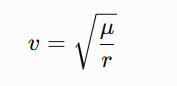
	​


In [67]:
def circular_orbit_velocity(radius):
    return np.sqrt(MU_EARTH / radius)

In [68]:
v_leo = circular_orbit_velocity(LEO_RADIUS)
v_meo = circular_orbit_velocity(MEO_RADIUS)

print("LEO velocity:", v_leo / 1e3, "km/s")
print("MEO velocity:", v_meo / 1e3, "km/s")

LEO velocity: 7.557865206532813 km/s
MEO velocity: 3.872635479854658 km/s


##Actually moving the satellites

For a circular orbit:

$$ \theta(t)=\theta_0+nt $$

We'll choose different starting positions.

In [69]:
LEO_PHASE = 0.0
MEO_PHASE = np.deg2rad(90)

In [70]:
def circular_orbit_position(radius, angular_velocity, time, phase=0.0):
    theta = phase + angular_velocity * time

    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = 0.0

    return np.array([x, y, z])

## Testing one moment in time

In [71]:
t = 100.0

leo_position = circular_orbit_position(
    LEO_RADIUS,
    n_leo,
    t,
    LEO_PHASE
)

meo_position = circular_orbit_position(
    MEO_RADIUS,
    n_meo,
    t,
    MEO_PHASE
)

print("LEO position [km]:")
print(leo_position / 1e3)

print("\nMEO position [km]:")
print(meo_position / 1e3)

print("\nThese three numbers are [x,y,z] in our earth centric coordinate system")


LEO position [km]:
[6937.24821444  754.30975201    0.        ]

MEO position [km]:
[ -387.24984501 26575.31568859     0.        ]

These three numbers are [x,y,z] in our earth centric coordinate system


Now calculate velocity too

For circular motion:

$$ v_x=-rn\sin\theta $$
$$ v_y=rn\cos\theta $$


In [72]:
def circular_orbit_state(radius, angular_velocity, time, phase=0.0):
    theta = phase + angular_velocity * time

    # Position
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = 0.0

    # Velocity
    vx = -radius * angular_velocity * np.sin(theta)
    vy =  radius * angular_velocity * np.cos(theta)
    vz = 0.0

    position = np.array([x, y, z])
    velocity = np.array([vx, vy, vz])

    return position, velocity

In [73]:
leo_position, leo_velocity = circular_orbit_state(
    LEO_RADIUS,
    n_leo,
    t,
    LEO_PHASE
)

meo_position, meo_velocity = circular_orbit_state(
    MEO_RADIUS,
    n_meo,
    t,
    MEO_PHASE
)

In [74]:
print("LEO")
print("Position [km]:", leo_position / 1e3)
print("Velocity [km/s]:", leo_velocity / 1e3)

print("\nMEO")
print("Position [km]:", meo_position / 1e3)
print("Velocity [km/s]:", meo_velocity / 1e3)

LEO
Position [km]: [6937.24821444  754.30975201    0.        ]
Velocity [km/s]: [-0.81697614  7.51357947  0.        ]

MEO
Position [km]: [ -387.24984501 26575.31568859     0.        ]
Velocity [km/s]: [-3.87222439 -0.05642523  0.        ]


# Propagate an entire orbit

First calculate orbital period:

$$ T = {\frac{2\pi}{n}} $$


In [75]:
T_leo = 2 * np.pi / n_leo
T_meo = 2 * np.pi / n_meo

print("LEO period:", T_leo / 60, "minutes")
print("MEO period:", T_meo / 3600, "hours")

LEO period: 96.68719643210862 minutes
MEO period: 11.978302685837544 hours


Generate the trajectory

Let's simulate 24 hours:

In [76]:
simulation_time = 24 * 3600
num_steps = 2000

times = np.linspace(0, simulation_time, num_steps)

In [77]:
leo_positions = []
meo_positions = []

for t in times:

    leo_pos, _ = circular_orbit_state(
        LEO_RADIUS,
        n_leo,
        t,
        LEO_PHASE
    )

    meo_pos, _ = circular_orbit_state(
        MEO_RADIUS,
        n_meo,
        t,
        MEO_PHASE
    )

    leo_positions.append(leo_pos)
    meo_positions.append(meo_pos)

leo_positions = np.array(leo_positions)
meo_positions = np.array(meo_positions)

leo_positions.shape

(2000, 3)

# Plotting

***Note: No inclination added so both sattelites are on the equitorial plane.***

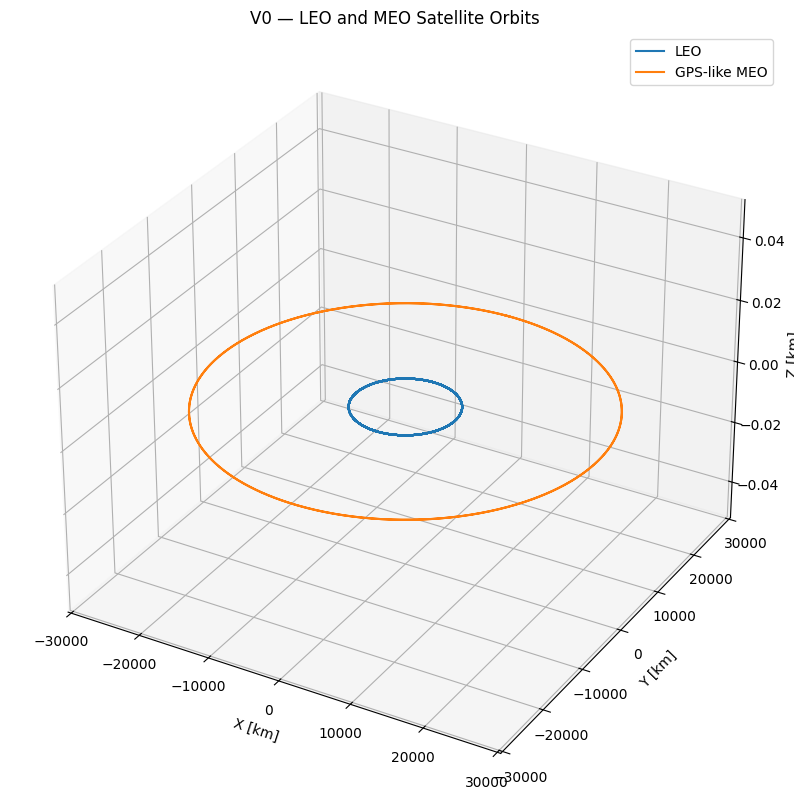

In [78]:
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection="3d")

ax.plot(
    leo_positions[:, 0] / 1e3,
    leo_positions[:, 1] / 1e3,
    leo_positions[:, 2] / 1e3,
    label="LEO"
)

ax.plot(
    meo_positions[:, 0] / 1e3,
    meo_positions[:, 1] / 1e3,
    meo_positions[:, 2] / 1e3,
    label="GPS-like MEO"
)

ax.set_xlabel("X [km]")
ax.set_ylabel("Y [km]")
ax.set_zlabel("Z [km]")

ax.set_title("V0 — LEO and MEO Satellite Orbits")

ax.legend()

plt.show()

### Interactive 3D Plot using Plotly

To create interactive 3D plots, `plotly` is a powerful and widely used library that integrates well with Google Colab. This example will plot the LEO and MEO orbits, allowing you to interact with the visualization directly.

In [79]:
import plotly.express as px
import pandas as pd

# Prepare data for Plotly
# Combine LEO and MEO positions into a single DataFrame
leo_df = pd.DataFrame(leo_positions / 1e3, columns=['X', 'Y', 'Z'])
leo_df['Orbit'] = 'LEO'

meo_df = pd.DataFrame(meo_positions / 1e3, columns=['X', 'Y', 'Z'])
meo_df['Orbit'] = 'GPS-like MEO'

full_df = pd.concat([leo_df, meo_df])

# Create the interactive 3D plot
fig = px.line_3d(
    full_df,
    x='X', y='Y', z='Z',
    color='Orbit',
    title='Interactive V0 — LEO and MEO Satellite Orbits (Plotly)',
    height=700,
    width=900
)

fig.update_layout(scene_aspectmode='data') # Ensure aspect ratio is consistent
fig.show()

In [80]:
leo_radii = np.linalg.norm(leo_positions, axis=1)
meo_radii = np.linalg.norm(meo_positions, axis=1)

print("LEO radius variation:",
      np.min(leo_radii) / 1e3,
      "to",
      np.max(leo_radii) / 1e3,
      "km")

print("MEO radius variation:",
      np.min(meo_radii) / 1e3,
      "to",
      np.max(meo_radii) / 1e3,
      "km")

LEO radius variation: 6978.136999999999 to 6978.137000000001 km
MEO radius variation: 26578.136999999995 to 26578.137000000002 km


In [81]:
leo_error = np.max(np.abs(leo_radii - LEO_RADIUS))
meo_error = np.max(np.abs(meo_radii - MEO_RADIUS))

print(f"Maximum LEO radius error: {leo_error:.12e} m")
print(f"Maximum MEO radius error: {meo_error:.12e} m")

Maximum LEO radius error: 9.313225746155e-10 m
Maximum MEO radius error: 3.725290298462e-09 m


In [82]:
print(
    "LEO relative error:",
    leo_error / LEO_RADIUS
)

print(
    "MEO relative error:",
    meo_error / MEO_RADIUS
)

LEO relative error: 1.3346292493476102e-16
MEO relative error: 1.401637104384673e-16
